# CohortFACTM vs MOFA+ multi-group — porównanie na COVID

Najpierw **sanity check** (sek. 1): czy dwa modele *bez* priora kohortowego — FACTM baseline
i MOFA+ single-group — dają to samo? Jeśli tak, w dalszych testach nie powtarzamy obu i
skupiamy się na **głównym porównaniu**: **CohortFACTM vs MOFA+ multi-group** (oba świadome
kohort a priori).

| Sekcja | Test | all_evaluation |
|--------|------|----------------|
| 1 | sanity: baseline vs MOFA single | — |
| 2 | dane (3 partycje) | 1 |
| 3 | profile kohortowe | 2–4 |
| 4 | K-sweep R² | 2 |
| 5 | struktura `Z` + faktor↔WHO (Spearman) | 7 |
| 6 | odległości kohort vs WHO (Spearman) | 5 |
| 7 | klastrowanie / odzysk (Z i Ŷ) | 8 |
| 8 | dlaczego MOFA multi nisko (centrowanie) | — |
| 9 | ładunki `W`, istotność, top-cechy, R² faktor×widok/kohorta | 9 |
| 10 | podsumowanie | 10 |

**Pominięte:** sweep `pi` (MOFA nie ma `π`), ELBO (inna skala między rodzinami).

> **Gdzie mierzymy.** MOFA+ multi-group **centruje `Z` per grupa** (`mean Z ≈ 0` per kohorta),
> więc metryki w `Z` (corr `Z`↔WHO, k-means w `Z`) są dla multi artefaktem. Profil multi czytamy
> z `std(Z)` per kohorta; klastrowanie liczymy też w **`Ŷ = Z·Wᵀ`** (uczciwe dla obu). Korelacje
> z WHO — **Spearman** (porządkowe).


## 0 — Setup, modele, cache

In [1]:
import os, sys, time, warnings, subprocess
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore')

try:
    from mofapy2.run.entry_point import entry_point
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'mofapy2', '-q'])
    from mofapy2.run.entry_point import entry_point

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score, adjusted_mutual_info_score,
                             homogeneity_completeness_v_measure, fowlkes_mallows_score)

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from covid_data.load_covid import load_covid

import src.build_model as _bm
_bm.tqdm = lambda x, *a, **k: x

sns.set_context('notebook'); pd.set_option('display.width', 140)
K, PI, MAX_ITER, SEED = 5, 0.5, 60, 0
MODES = ['per_severity', 'grouped', 'binary']
VIEW_NAMES = ['metabolom', 'proteom']
MODELS = ['CohortFACTM', 'MOFA+ multi-group']    # główne porównanie (dalsze sekcje)
print(f'K={K}  pi={PI}  MAX_ITER={MAX_ITER}  | główne: CohortFACTM vs MOFA+ multi-group')

K=5  pi=0.5  MAX_ITER=60  | główne: CohortFACTM vs MOFA+ multi-group


In [2]:
# ---------------- FACTM ----------------
def fit_factm(views, cohort):
    zp = [ZPrior.COHORT] * K if cohort else [ZPrior.STD_NORMAL] * K
    kw = dict(cohort_prior_config=CohortPriorConfig(pi=PI)) if cohort else {}
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                             for _ in range(views.num_simple)],
        structured_view_configs=[], z_priors=zp, **kw)
    m = FACTModel(views=views, K=K, model_config=cfg, seed=SEED)
    m.fit(max_iter=MAX_ITER, pretrain=True, elbo_tres=0.0)
    return m


def factm_gamma_delta(m):
    pr = m.fa.node_z.z_priors
    return (np.column_stack([pr[k].E_gamma for k in range(K)]),
            np.column_stack([pr[k].E_delta for k in range(K)]))


def factm_W(m, vi=0):
    return np.asarray(m.fa.nodelist_w[vi].E_w)


# ---------------- MOFA+ ----------------
def fit_mofa(covid, multi):
    views, coh = covid.views, covid.cohorts
    if multi:
        groups = [str(c) for c in sorted(np.unique(coh))]
        samples = [covid.sample_ids[coh == g].tolist() for g in groups]
        data = [[np.asarray(views.simple[vi].data)[coh == g] for g in groups]
                for vi in range(views.num_simple)]
    else:
        groups, samples = ['all'], [covid.sample_ids.tolist()]
        data = [[np.asarray(views.simple[vi].data)] for vi in range(views.num_simple)]
    ent = entry_point()
    ent.set_data_options(scale_views=False)
    ent.set_data_matrix(data, views_names=VIEW_NAMES, groups_names=groups, samples_names=samples)
    ent.set_model_options(factors=K, ard_weights=True, ard_factors=multi, spikeslab_weights=True)
    ent.set_train_options(iter=MAX_ITER, convergence_mode='fast', seed=SEED, verbose=False)
    ent.build(); ent.run()
    ent._groups, ent._multi = groups, multi
    return ent


def mofa_Z(ent, covid):
    Z = ent.model.getExpectations()['Z']['E']
    if getattr(ent, '_multi', False):
        ids = np.concatenate([covid.sample_ids[covid.cohorts == g].tolist()
                              for g in getattr(ent, '_groups')])
        order = {s: i for i, s in enumerate(ids)}
        return Z[[order[s] for s in covid.sample_ids]]
    return Z


def mofa_W(ent, vi=0):
    return ent.model.getExpectations()['W'][vi]['E']

In [3]:
# ---------------- wspólne ----------------
def cohort_dist(M):
    d = M[:, None, :] - M[None, :, :]
    return np.sqrt((d ** 2).sum(-1))


def severity_from_label(label):
    s = str(label).strip().lower()
    if s in ('mild', 'moderate', 'severe'):
        return {'mild': 0.5, 'moderate': 3.0, 'severe': 6.0}[s]
    if s.startswith('sev') and s[3:].isdigit():
        return float(s[3:])
    return {'non_hosp': 1.0, 'hosp': 5.0}.get(s, float('nan'))


def spear(a, b):
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float('nan')
    return float(spearmanr(a, b)[0])


def clustering_row(X, codes, C):
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(X)
    _, _, v = homogeneity_completeness_v_measure(codes, lab)
    return {'silhouette': float(silhouette_score(X, codes)),
            'ARI': float(adjusted_rand_score(codes, lab)),
            'NMI': float(normalized_mutual_info_score(codes, lab)),
            'AMI': float(adjusted_mutual_info_score(codes, lab)),
            'V_measure': float(v),
            'FMI': float(fowlkes_mallows_score(codes, lab))}


def hungarian(Za, Zb):
    Cm = np.abs(np.corrcoef(Za.T, Zb.T)[:Za.shape[1], Za.shape[1]:])
    perm, _ = linear_sum_assignment(-Cm)
    return perm


# ---------------- cache ----------------
DATA, FITS, MOFA_FITS = {}, {}, {}
FACTM_CACHE, MOFA_CACHE = '.fit_cache', '.mofa_cache'
os.makedirs(FACTM_CACHE, exist_ok=True); os.makedirs(MOFA_CACHE, exist_ok=True)


def get_data(mode):
    if mode not in DATA:
        DATA[mode] = load_covid(cohort_mode=mode, standardize=True)
    return DATA[mode]


def get_factm(mode, cohort, k=K):
    key = (mode, 'cohort' if cohort else 'baseline', k, round(PI, 3) if cohort else None, MAX_ITER, SEED)
    if key in FITS:
        return FITS[key]
    path = os.path.join(FACTM_CACHE, '_'.join(str(x) for x in key).replace('.', 'p') + '.joblib')
    if os.path.exists(path):
        FITS[key] = joblib.load(path); return FITS[key]
    global K
    K_save = K; K = k
    m = fit_factm(get_data(mode).views, cohort); K = K_save
    print(f'  [FACTM] {mode} {"cohort" if cohort else "baseline"} K={k}')
    joblib.dump(m, path, compress=3); FITS[key] = m; return m


def get_mofa(mode, multi, k=K):
    key = (mode, 'multi' if multi else 'single', k, MAX_ITER, SEED)
    if key in MOFA_FITS:
        return MOFA_FITS[key]
    path = os.path.join(MOFA_CACHE, '_'.join(str(x) for x in key) + '.joblib')
    if os.path.exists(path):
        MOFA_FITS[key] = joblib.load(path); return MOFA_FITS[key]
    global K
    K_save = K; K = k
    ent = fit_mofa(get_data(mode), multi); K = K_save
    print(f'  [MOFA+] {mode} {"multi" if multi else "single"} K={k}')
    joblib.dump(ent, path, compress=3); MOFA_FITS[key] = ent; return ent


# ---------------- akcesory per model ----------------
def get_Z(mode, label):
    d = get_data(mode)
    if label == 'CohortFACTM':       return np.asarray(get_factm(mode, True).get_latent_factors())
    if label == 'FACTM baseline':    return np.asarray(get_factm(mode, False).get_latent_factors())
    if label == 'MOFA+ multi-group': return mofa_Z(get_mofa(mode, True), d)
    if label == 'MOFA+ single-group': return mofa_Z(get_mofa(mode, False), d)
    raise ValueError(label)


def get_W_view(mode, label, vi):
    if label == 'CohortFACTM':       return factm_W(get_factm(mode, True), vi)
    if label == 'FACTM baseline':    return factm_W(get_factm(mode, False), vi)
    if label == 'MOFA+ multi-group': return mofa_W(get_mofa(mode, True), vi)
    if label == 'MOFA+ single-group': return mofa_W(get_mofa(mode, False), vi)


def get_Yhat(mode, label):
    Z = get_Z(mode, label); ns = get_data(mode).views.num_simple
    return np.hstack([Z @ get_W_view(mode, label, vi).T for vi in range(ns)])


def get_r2(mode, label):
    d = get_data(mode); Z = get_Z(mode, label); rs = []
    for vi in range(d.views.num_simple):
        Y = np.asarray(d.views.simple[vi].data); Yh = Z @ get_W_view(mode, label, vi).T
        rs.append(1 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum())
    return float(np.mean(rs))


def get_profile(mode, label):
    '''(C, K) profil kohortowy — wlasciwa reprezentacja per model.'''
    d = get_data(mode); names = np.array(sorted(np.unique(d.cohorts)))
    if label == 'CohortFACTM':
        E_g, E_d = factm_gamma_delta(get_factm(mode, True)); return E_g * E_d, names
    Z = get_Z(mode, label)
    if label == 'MOFA+ multi-group':
        return np.array([Z[d.cohorts == c].std(0) for c in names]), names
    return np.array([Z[d.cohorts == c].mean(0) for c in names]), names

## 1 — Sanity check: FACTM baseline vs MOFA+ single-group

Oba modele są **bez priora kohortowego** (wspólne `Z`, brak wiedzy o grupach). Jeśli dają
ten sam wynik, to dwa „zwykłe" modele FA są równoważne — i w dalszych sekcjach nie musimy
trzymać obu jako referencji. Sprawdzamy: pokrycie podprzestrzeni `Z` (1.0 = te same kierunki)
oraz R²/silhouette/odzysk kohort.


In [4]:
mode = 'per_severity'; d = get_data(mode)
_, codes = np.unique(d.cohorts, return_inverse=True); C = len(np.unique(codes))


def subspace_overlap(A, B):
    Qa = np.linalg.qr(A - A.mean(0))[0]; Qb = np.linalg.qr(B - B.mean(0))[0]
    return float(np.linalg.svd(Qa.T @ Qb, compute_uv=False).mean())


rows = [{'model': label, 'R2': round(get_r2(mode, label), 3),
         **{k: round(v, 3) for k, v in clustering_row(get_Z(mode, label), codes, C).items()}}
        for label in ['FACTM baseline', 'MOFA+ single-group']]
print('FACTM baseline vs MOFA+ single-group (per_severity, K=5):')
print(pd.DataFrame(rows).to_string(index=False))
ov = subspace_overlap(get_Z(mode, 'FACTM baseline'), get_Z(mode, 'MOFA+ single-group'))
print(f'\nPokrycie podprzestrzeni Z (baseline vs MOFA single): {ov:.3f}  (1.0 = te same kierunki utajone)')
print('→ Ten sam wynik => oba "zwykłe" FA są równoważne. Dalej porównujemy już tylko'
      ' CohortFACTM vs MOFA+ multi-group.')

FACTM baseline vs MOFA+ single-group (per_severity, K=5):
             model    R2  silhouette   ARI   NMI   AMI  V_measure   FMI
    FACTM baseline 0.392       0.169 0.554 0.504 0.485      0.504 0.647
MOFA+ single-group 0.391       0.161 0.424 0.460 0.440      0.460 0.543

Pokrycie podprzestrzeni Z (baseline vs MOFA single): 1.000  (1.0 = te same kierunki utajone)
→ Ten sam wynik => oba "zwykłe" FA są równoważne. Dalej porównujemy już tylko CohortFACTM vs MOFA+ multi-group.


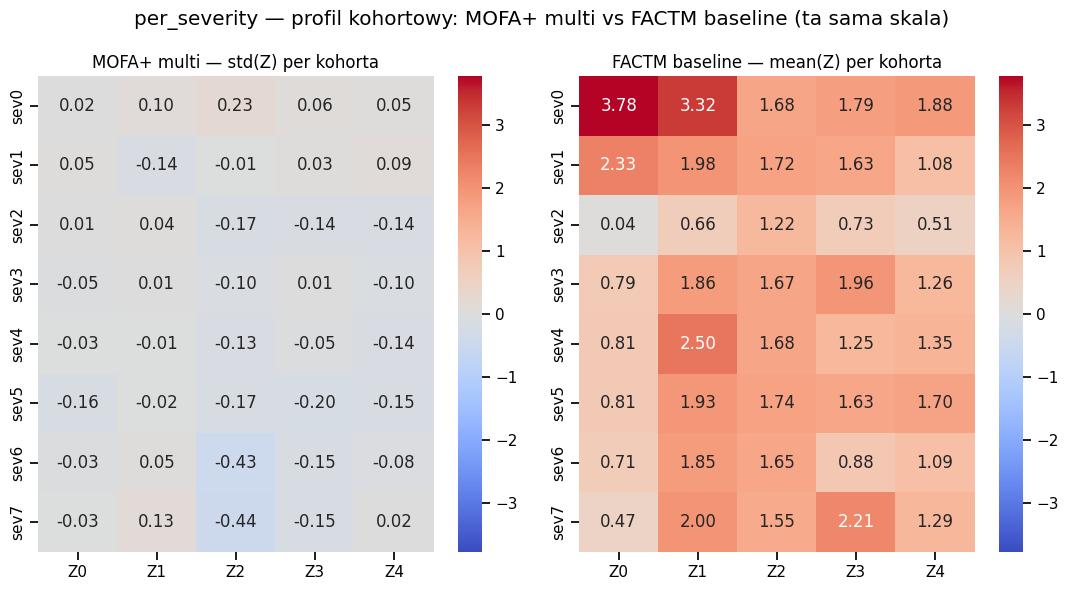

In [6]:
# porównanie: FACTM baseline vs MOFA+ multi — ta sama skala kolorów
mode = 'per_severity'
d = get_data(mode)
prof_base, names = get_profile(mode, 'FACTM baseline')
prof_mofa, _ = get_profile(mode, 'MOFA+ multi-group')
fl = [f'Z{k}' for k in range(K)]
vmax = max(np.abs(prof_base).max(), np.abs(prof_mofa).max())

fig, axes = plt.subplots(1, 2, figsize=(11, 0.5 * len(names) + 2))
sns.heatmap(prof_base, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[0])
axes[0].set_title('MOFA+ multi — std(Z) per kohorta')
sns.heatmap(prof_mofa, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=fl, yticklabels=names, ax=axes[1])
axes[1].set_title('FACTM baseline — mean(Z) per kohorta')
plt.suptitle(f'{mode} — profil kohortowy: MOFA+ multi vs FACTM baseline (ta sama skala)')
plt.tight_layout(); plt.show()

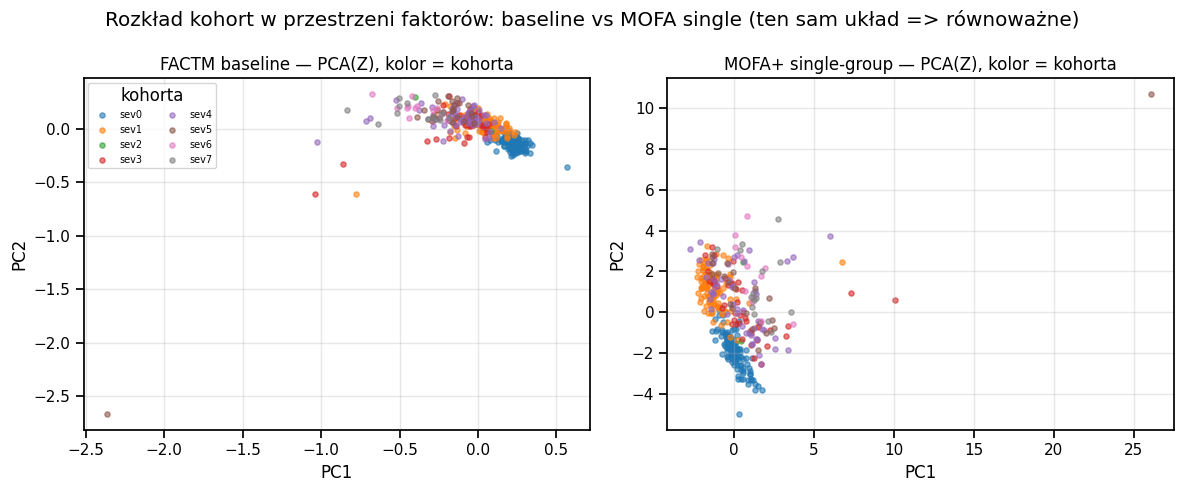

Korelacja centroidów faktor×kohorta (po stand. i Hungarianie): 0.020
→ NISKA, mimo pokrycia podprzestrzeni = 1.0: faktory baseline i single są wzajemnie OBRÓCONE w obrębie tej samej podprzestrzeni. To ilustruje, że faktorów NIE wolno porównywać 1:1 między modelami — porównujemy podprzestrzeń / PCA / niezmienniki.


In [5]:
# Wizualnie: rozkład próbek w przestrzeni faktorów PCA(Z), kolor = kohorta.
# PCA jest odporne na obrót/skalę faktorów WEWNĄTRZ wspólnej podprzestrzeni, więc dla
# równoważnych modeli układ kohort wygląda tak samo (z dokładnością do obrotu/odbicia osi).
mode = 'per_severity'; d = get_data(mode)
names, codes = np.unique(d.cohorts, return_inverse=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label in zip(axes, ['FACTM baseline', 'MOFA+ single-group']):
    P = PCA(2).fit_transform(get_Z(mode, label))
    for i, nm in enumerate(names):
        m = codes == i
        ax.scatter(P[m, 0], P[m, 1], s=14, alpha=0.6, label=nm)
    ax.set_title(f'{label} — PCA(Z), kolor = kohorta')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle('Rozkład kohort w przestrzeni faktorów: baseline vs MOFA single (ten sam układ => równoważne)')
plt.tight_layout(); plt.show()

# Dlaczego NIE pokazujemy heatmapy faktor×kohorta dla porównania 1:1:
Zb = get_Z(mode, 'FACTM baseline'); Zs = get_Z(mode, 'MOFA+ single-group')
perm = hungarian(Zb, Zs)
Cb = np.array([Zb[codes == i].mean(0) / Zb.std(0) for i in range(len(names))])
Cs = np.array([(Zs[:, perm] / Zs[:, perm].std(0))[codes == i].mean(0) for i in range(len(names))])
print(f'Korelacja centroidów faktor×kohorta (po stand. i Hungarianie): '
      f'{float(np.corrcoef(Cb.ravel(), Cs.ravel())[0, 1]):.3f}')
print('→ NISKA, mimo pokrycia podprzestrzeni = 1.0: faktory baseline i single są wzajemnie'
      ' OBRÓCONE w obrębie tej samej podprzestrzeni. To ilustruje, że faktorów NIE wolno'
      ' porównywać 1:1 między modelami — porównujemy podprzestrzeń / PCA / niezmienniki.')

### Uwaga: jak (nie) porównywać faktorów i co znaczą liczby na wykresach

**Faktory nie są wspólne między modelami** (permutacja, znak, skala — `Y=Z·Wᵀ` niezmiennicze
na `Z→cZ, W→W/c`). Porównanie „Z0 vs Z0" między modelami **nie ma sensu**. Używamy tylko
niezmienników: `R²`, korelacje z WHO (Spearman), odzysk klastrów, oraz `|corr(W)|` **po
dopasowaniu Hungarian** (sek. 9).

**Liczby na wykresach MOFA+ (często >1)** to **nie** prawdopodobieństwa: `std(Z)` to rozrzut
faktora w kohorcie, a `W` to ładunki w skali MOFA (`Z`≈wariancja jednostkowa → skala w `W`).
Wartości bezwzględne MOFA i FACTM nie są wprost porównywalne. Wyjątek: `E[γ]`∈[0,1] w
CohortFACTM = prawdopodobieństwo aktywacji.


## 2 — Dane: trzy partycje kohort

In [6]:
for mode in MODES:
    d = get_data(mode)
    print(f'=== {mode} ===  N={d.views.N}  C={len(np.unique(d.cohorts))}')
    print(pd.Series(d.cohorts).value_counts().sort_index().to_string(), '\n')

=== per_severity ===  N=378  C=8
sev0    124
sev1    104
sev2      2
sev3     44
sev4     55
sev5     22
sev6     12
sev7     15 

=== grouped ===  N=378  C=3
mild        228
moderate    101
severe       49 



=== binary ===  N=378  C=2
hosp        148
non_hosp    230 



## 3 — Profile kohortowe: CohortFACTM vs MOFA+ multi

`E[γ·δ]` i `E[γ]` (CohortFACTM) vs `std(Z)` per kohorta (MOFA multi — `mean Z ≈ 0`).
Skale osobne (różne reprezentacje), patrz uwaga wyżej.


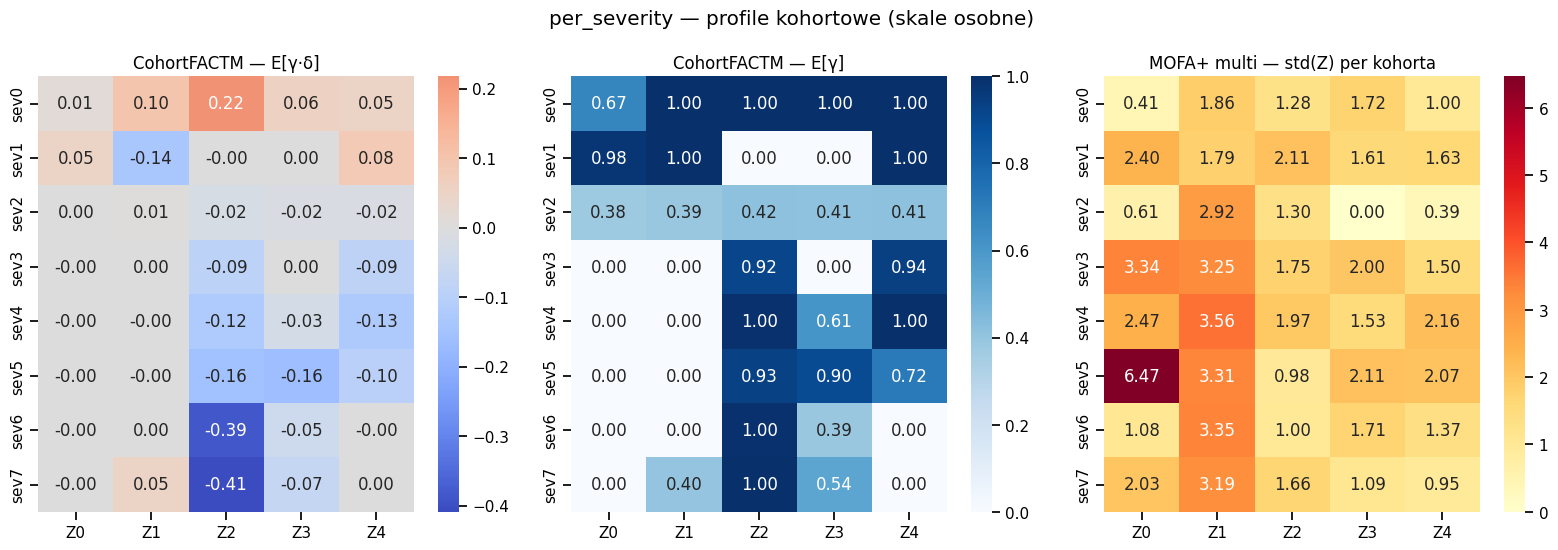

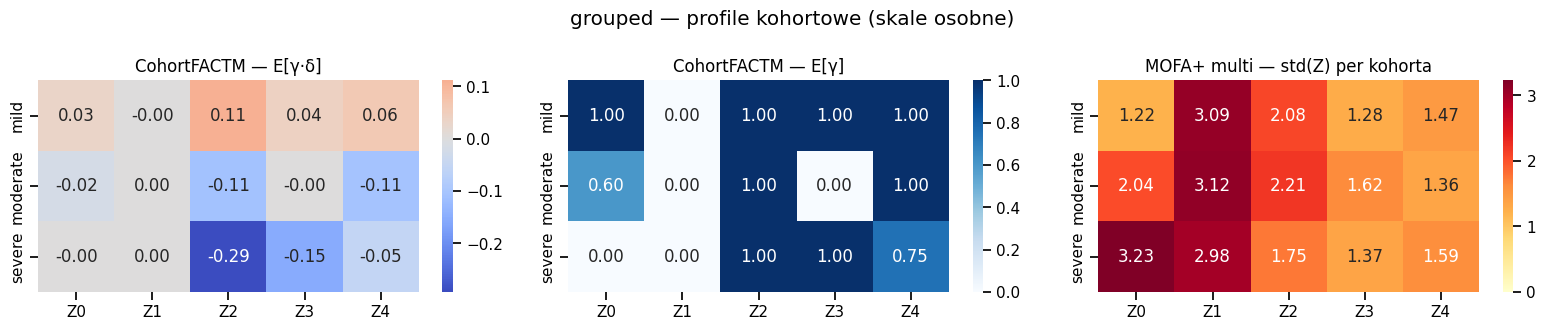

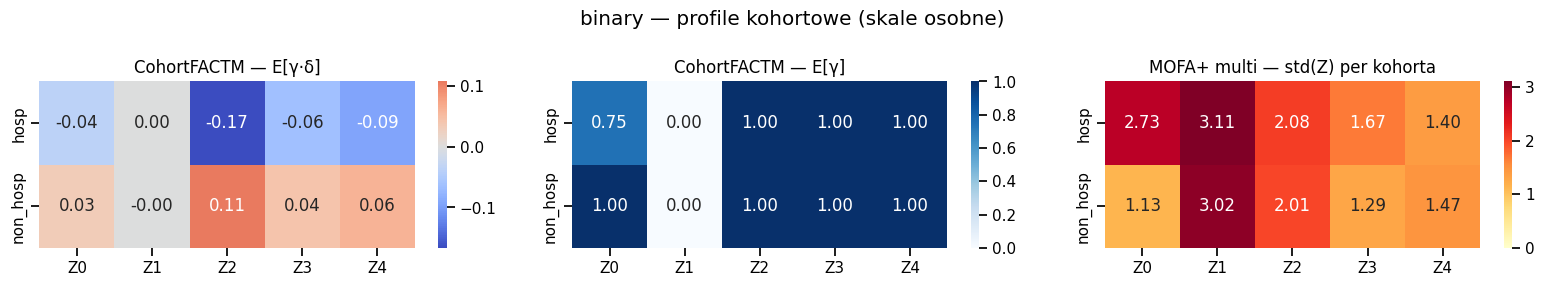

In [7]:
def plot_profiles(mode):
    d = get_data(mode); names = np.array(sorted(np.unique(d.cohorts))); fl = [f'Z{k}' for k in range(K)]
    E_g, E_d = factm_gamma_delta(get_factm(mode, True))
    prof_mm, _ = get_profile(mode, 'MOFA+ multi-group')
    fig, axes = plt.subplots(1, 3, figsize=(16, 0.45 * len(names) + 2))
    sns.heatmap(E_g * E_d, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                xticklabels=fl, yticklabels=names, ax=axes[0]); axes[0].set_title('CohortFACTM — E[γ·δ]')
    sns.heatmap(E_g, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=fl, yticklabels=names, ax=axes[1]); axes[1].set_title('CohortFACTM — E[γ]')
    sns.heatmap(prof_mm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0,
                xticklabels=fl, yticklabels=names, ax=axes[2]); axes[2].set_title('MOFA+ multi — std(Z) per kohorta')
    plt.suptitle(f'{mode} — profile kohortowe (skale osobne)'); plt.tight_layout(); plt.show()

for mode in MODES:
    plot_profiles(mode)

## 4 — K-sweep: R² rekonstrukcji vs liczba czynników

`R²` jest porównywalne między rodzinami (ELBO nie). `K ∈ {3,5,10}`, `per_severity`.


R² rekonstrukcji vs K (per_severity):
model  CohortFACTM  MOFA+ multi-group
K                                    
3            0.335              0.166
5            0.392              0.225
10           0.485              0.281


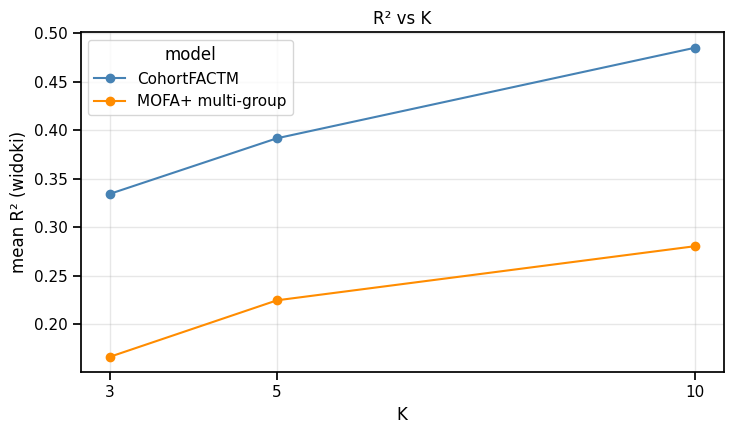

In [8]:
mode = 'per_severity'; d = get_data(mode); rows = []
for k in [3, 5, 10]:
    for label in MODELS:
        if label == 'CohortFACTM':
            m = get_factm(mode, True, k); Z = np.asarray(m.get_latent_factors())
            Ws = [factm_W(m, vi) for vi in range(d.views.num_simple)]
        else:
            ent = get_mofa(mode, True, k); Z = mofa_Z(ent, d)
            Ws = [mofa_W(ent, vi) for vi in range(d.views.num_simple)]
        rs = [1 - ((np.asarray(d.views.simple[vi].data) - Z @ Ws[vi].T) ** 2).sum() /
              ((np.asarray(d.views.simple[vi].data) - np.asarray(d.views.simple[vi].data).mean(0)) ** 2).sum()
              for vi in range(d.views.num_simple)]
        rows.append({'K': k, 'model': label, 'R2': float(np.mean(rs))})
piv = pd.DataFrame(rows).pivot(index='K', columns='model', values='R2')[MODELS]
print('R² rekonstrukcji vs K (per_severity):'); print(piv.round(3).to_string())
ax = piv.plot(marker='o', figsize=(7.5, 4.5), color=['steelblue', 'darkorange'])
ax.set_ylabel('mean R² (widoki)'); ax.set_xlabel('K'); ax.set_xticks([3, 5, 10])
ax.set_title('R² vs K'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5 — Struktura czynników `Z` i powiązanie z nasileniem (Spearman)

1. `corr(Zᵀ)` (Pearson) — struktura faktor↔faktor, per model (off-diag ~0 = dobra faktoryzacja).
2. Który faktor śledzi WHO — `|ρ|` profilu kohortowego z rangą nasilenia, **sortowane w obrębie
   modelu** (faktory nie są wspólne między modelami).


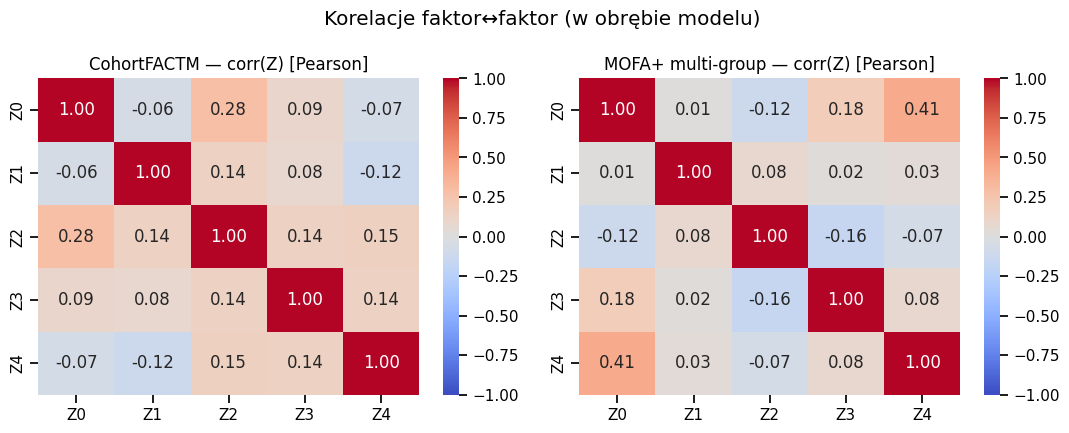

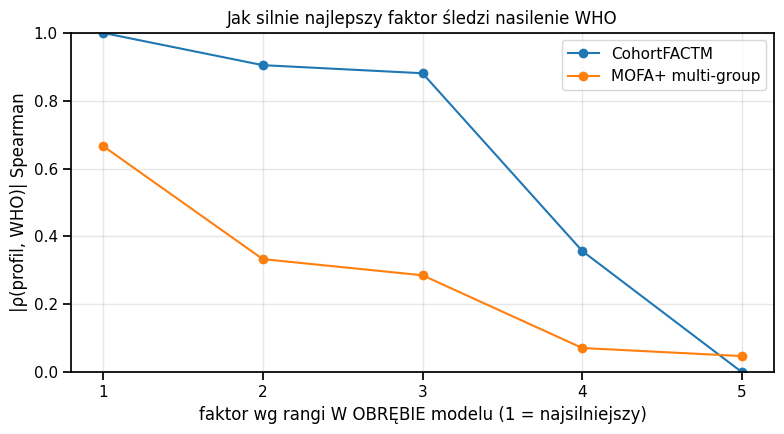

            model najlepszy_faktor (w modelu)  |ρ(WHO)|
      CohortFACTM                          Z2     1.000
MOFA+ multi-group                          Z1     0.667


In [9]:
mode = 'per_severity'; d = get_data(mode); names = np.array(sorted(np.unique(d.cohorts)))
sev_rank = np.array([severity_from_label(c) for c in names]); fl = [f'Z{k}' for k in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, label in zip(axes, MODELS):
    sns.heatmap(np.corrcoef(get_Z(mode, label).T), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, xticklabels=fl, yticklabels=fl, ax=ax)
    ax.set_title(f'{label} — corr(Z) [Pearson]')
plt.suptitle('Korelacje faktor↔faktor (w obrębie modelu)'); plt.tight_layout(); plt.show()

best = []
fig, ax = plt.subplots(figsize=(8, 4.5))
for label in MODELS:
    P, _ = get_profile(mode, label)
    cc = np.array([abs(spear(P[:, k], sev_rank)) for k in range(K)])
    ax.plot(range(1, K + 1), np.sort(cc)[::-1], 'o-', label=label)
    best.append({'model': label, 'najlepszy_faktor (w modelu)': f'Z{int(np.argmax(cc))}',
                 '|ρ(WHO)|': round(float(cc.max()), 3)})
ax.set_xlabel('faktor wg rangi W OBRĘBIE modelu (1 = najsilniejszy)')
ax.set_ylabel('|ρ(profil, WHO)| Spearman'); ax.set_ylim(0, 1); ax.set_xticks(range(1, K + 1))
ax.set_title('Jak silnie najlepszy faktor śledzi nasilenie WHO'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(pd.DataFrame(best).to_string(index=False))

## 6 — Odległości kohort vs gradient nasilenia WHO (Spearman)

`binary` pominięte (1 para). `grouped` (3 pary) — zgrubne.


In [10]:
rows = []
for mode in ['grouped', 'per_severity']:
    d = get_data(mode); names = np.array(sorted(np.unique(d.cohorts)))
    sev = np.array([severity_from_label(c) for c in names])
    D_sev = np.abs(sev[:, None] - sev[None, :]); tri = np.triu_indices(len(names), 1)
    row = {'mode': mode, 'n_par': len(tri[0])}
    for label in MODELS:
        P, _ = get_profile(mode, label)
        row[label] = round(spear(cohort_dist(P)[tri], D_sev[tri]), 3)
    rows.append(row)
print('Spearman ρ(odległość kohort, |różnica WHO|) — wyżej = lepiej:')
print(pd.DataFrame(rows).to_string(index=False))

Spearman ρ(odległość kohort, |różnica WHO|) — wyżej = lepiej:
        mode  n_par  CohortFACTM  MOFA+ multi-group
     grouped      3         0.50              1.000
per_severity     28         0.87             -0.131


## 7 — Klastrowanie / odzysk kohort (`Z` i `Ŷ`)

k-means `k = liczba kohort`, vs prawdziwe kohorty. W `Z` MOFA multi ma ARI≈0 (centrowanie),
więc kluczowa jest przestrzeń **`Ŷ = Z·Wᵀ`** (uczciwa dla obu).


In [11]:
def recovery_table(space):
    rows = []
    for mode in MODES:
        d = get_data(mode); _, codes = np.unique(d.cohorts, return_inverse=True); C = len(np.unique(codes))
        for label in MODELS:
            X = get_Z(mode, label) if space == 'Z' else get_Yhat(mode, label)
            rows.append({'mode': mode, 'model': label, 'R2': round(get_r2(mode, label), 3),
                         **{kk: round(vv, 3) for kk, vv in clustering_row(X, codes, C).items()}})
    return pd.DataFrame(rows)

df_Z = recovery_table('Z'); df_Y = recovery_table('Yhat')
print('=== Odzysk w Z ==='); print(df_Z.to_string(index=False))
print('\n=== Odzysk w Ŷ = Z·Wᵀ ==='); print(df_Y.to_string(index=False))

=== Odzysk w Z ===
        mode             model    R2  silhouette    ARI   NMI    AMI  V_measure   FMI
per_severity       CohortFACTM 0.392       0.174  0.555 0.506  0.487      0.506 0.648
per_severity MOFA+ multi-group 0.225      -0.098  0.034 0.073  0.039      0.073 0.222
     grouped       CohortFACTM 0.392       0.209  0.554 0.460  0.456      0.460 0.772
     grouped MOFA+ multi-group 0.291       0.004  0.009 0.009  0.002      0.009 0.473
      binary       CohortFACTM 0.392       0.277  0.003 0.007  0.002      0.007 0.722
      binary MOFA+ multi-group 0.301       0.025 -0.001 0.001 -0.001      0.001 0.511

=== Odzysk w Ŷ = Z·Wᵀ ===
        mode             model    R2  silhouette    ARI   NMI    AMI  V_measure   FMI
per_severity       CohortFACTM 0.392       0.187  0.525 0.493  0.475      0.493 0.625
per_severity MOFA+ multi-group 0.225      -0.117  0.027 0.054  0.019      0.054 0.214
     grouped       CohortFACTM 0.392       0.199  0.468 0.410  0.406      0.410 0.722
     gro

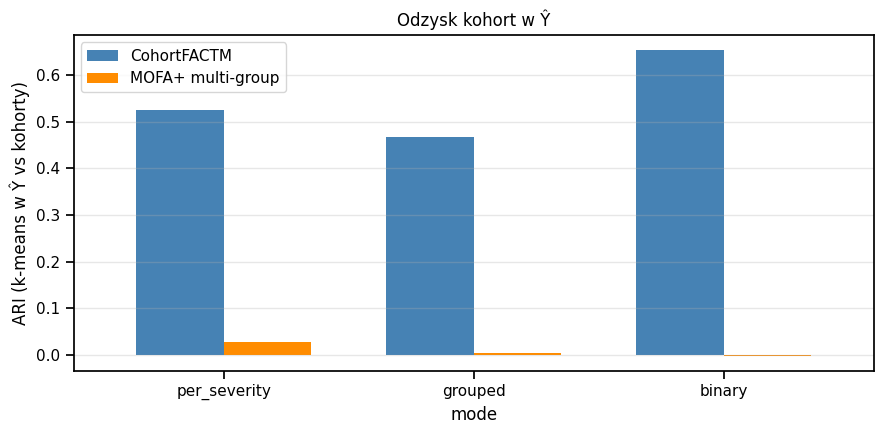

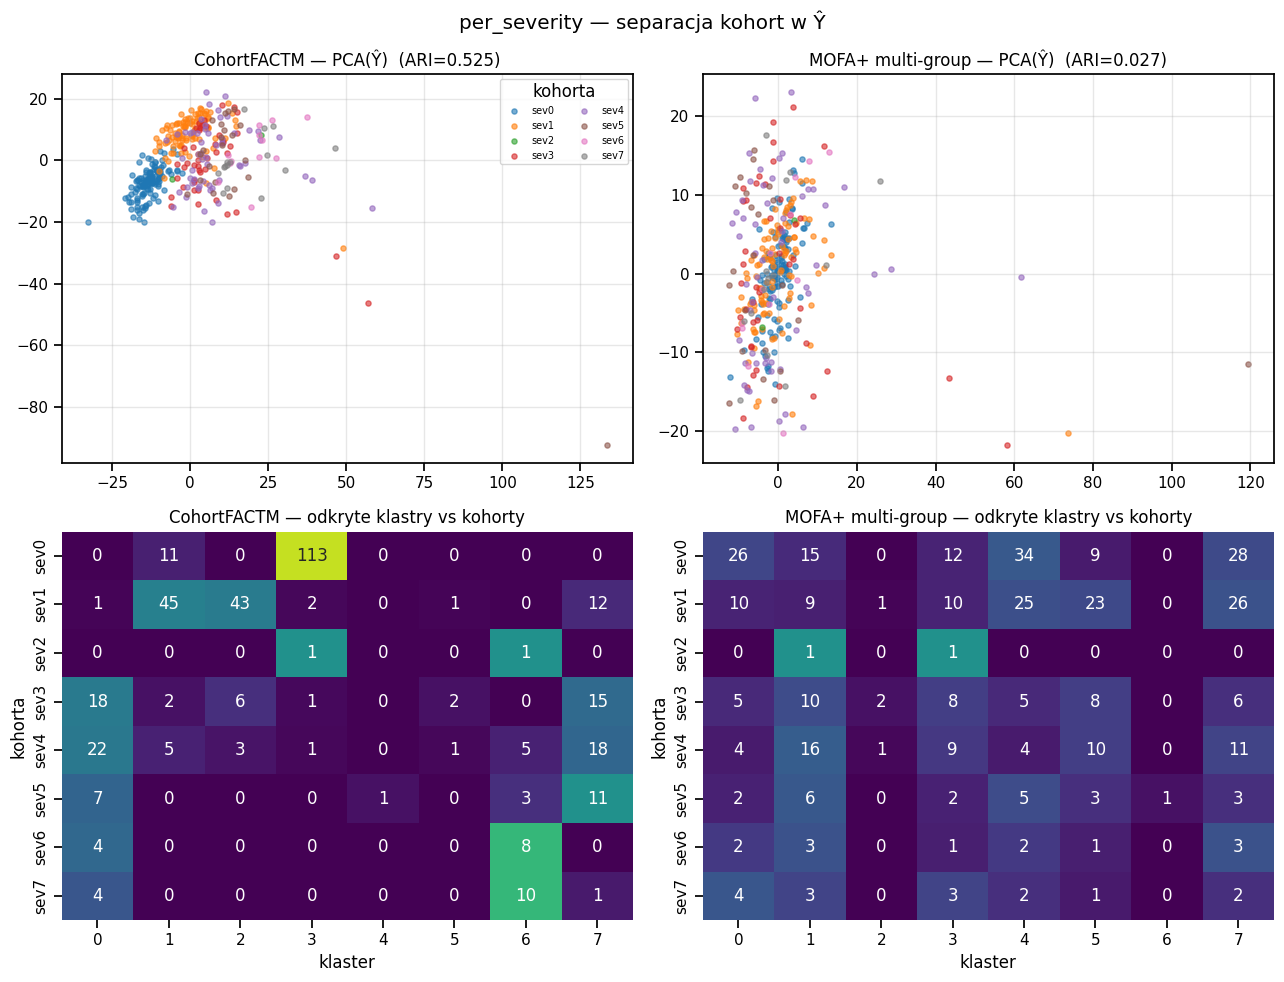

In [12]:
# ARI w Ŷ — 3 partycje
piv = df_Y.pivot(index='mode', columns='model', values='ARI')[MODELS].loc[MODES]
ax = piv.plot.bar(figsize=(9, 4.5), rot=0, color=['steelblue', 'darkorange'], width=0.7)
ax.set_ylabel('ARI (k-means w Ŷ vs kohorty)'); ax.set_title('Odzysk kohort w Ŷ')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

# PCA(Ŷ) + macierz zgodności — per_severity
mode = 'per_severity'; d = get_data(mode)
names, codes = np.unique(d.cohorts, return_inverse=True); C = len(names)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for col, label in enumerate(MODELS):
    Yh = get_Yhat(mode, label); P = PCA(2).fit_transform(Yh)
    for i, nm in enumerate(names):
        msk = codes == i
        axes[0, col].scatter(P[msk, 0], P[msk, 1], s=14, alpha=0.6, label=nm)
    ari = df_Y[(df_Y['mode'] == mode) & (df_Y['model'] == label)]['ARI'].iloc[0]
    axes[0, col].set_title(f'{label} — PCA(Ŷ)  (ARI={ari})'); axes[0, col].grid(alpha=0.3)
    lab = KMeans(n_clusters=C, n_init=10, random_state=0).fit_predict(Yh)
    ct = pd.crosstab(pd.Series(d.cohorts, name='kohorta'), pd.Series(lab, name='klaster'))
    sns.heatmap(ct.div(ct.sum(1), axis=0), annot=ct.values, fmt='d', cmap='viridis',
                vmin=0, vmax=1, ax=axes[1, col], cbar=False)
    axes[1, col].set_title(f'{label} — odkryte klastry vs kohorty')
axes[0, 0].legend(fontsize=7, ncol=2, title='kohorta')
plt.suptitle(f'{mode} — separacja kohort w Ŷ'); plt.tight_layout(); plt.show()

## 8 — Dlaczego MOFA multi-group ma niskie R²/odzysk?

MOFA multi **centruje `Z` per grupa** → usuwa różnice średnich między kohortami (gradient
ciężkości). To nie wada, to inny cel modelu (struktura *wewnątrz* grup).


In [13]:
mode = 'per_severity'; d = get_data(mode); coh = d.cohorts
names = np.array(sorted(np.unique(coh))); Zm = get_Z(mode, 'MOFA+ multi-group')
print('mean|mean(Z) per kohorta| =',
      round(np.mean([np.abs(Zm[coh == g].mean(0)).mean() for g in names]), 4),
      ' (≈0 => MOFA multi CENTRUJE Z per grupa => usuwa różnice średnich kohort)')
rows = []
for vi, vn in enumerate(VIEW_NAMES):
    Y = np.asarray(d.views.simple[vi].data); Yh = Zm @ get_W_view(mode, 'MOFA+ multi-group', vi).T
    Yc = Y.copy()
    for g in names:
        Yc[coh == g] = Y[coh == g] - Y[coh == g].mean(0)
    r2_glob = 1 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()
    r2_pgc = 1 - ((Yc - Yh) ** 2).sum() / ((Yc - Yc.mean(0)) ** 2).sum()
    btw = sum(np.sum(coh == g) * ((Y[coh == g].mean(0) - Y.mean(0)) ** 2).sum()
              for g in names) / ((Y - Y.mean(0)) ** 2).sum()
    rows.append({'widok': vn, 'R²_vs_global': round(r2_glob, 3),
                 'R²_vs_per-grupa-centr': round(r2_pgc, 3),
                 '%_wariancji_między-grupowej': round(btw * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print('→ MOFA multi odrzuca wariancję między-grupową; CohortFACTM modeluje ją jawnie przez γ·δ.')

mean|mean(Z) per kohorta| = 0.0  (≈0 => MOFA multi CENTRUJE Z per grupa => usuwa różnice średnich kohort)
    widok  R²_vs_global  R²_vs_per-grupa-centr  %_wariancji_między-grupowej
metabolom         0.192                  0.218                         11.7
  proteom         0.257                  0.351                         26.8
→ MOFA multi odrzuca wariancję między-grupową; CohortFACTM modeluje ją jawnie przez γ·δ.


## 9 — Ładunki `W`, istotność czynników, interpretacja

`E[W]` cohort vs MOFA multi (Hungarian) + `|corr(W)|`; względna energia (dopasowana);
top-cechy per faktor; R² faktor×widok / faktor×kohorta.


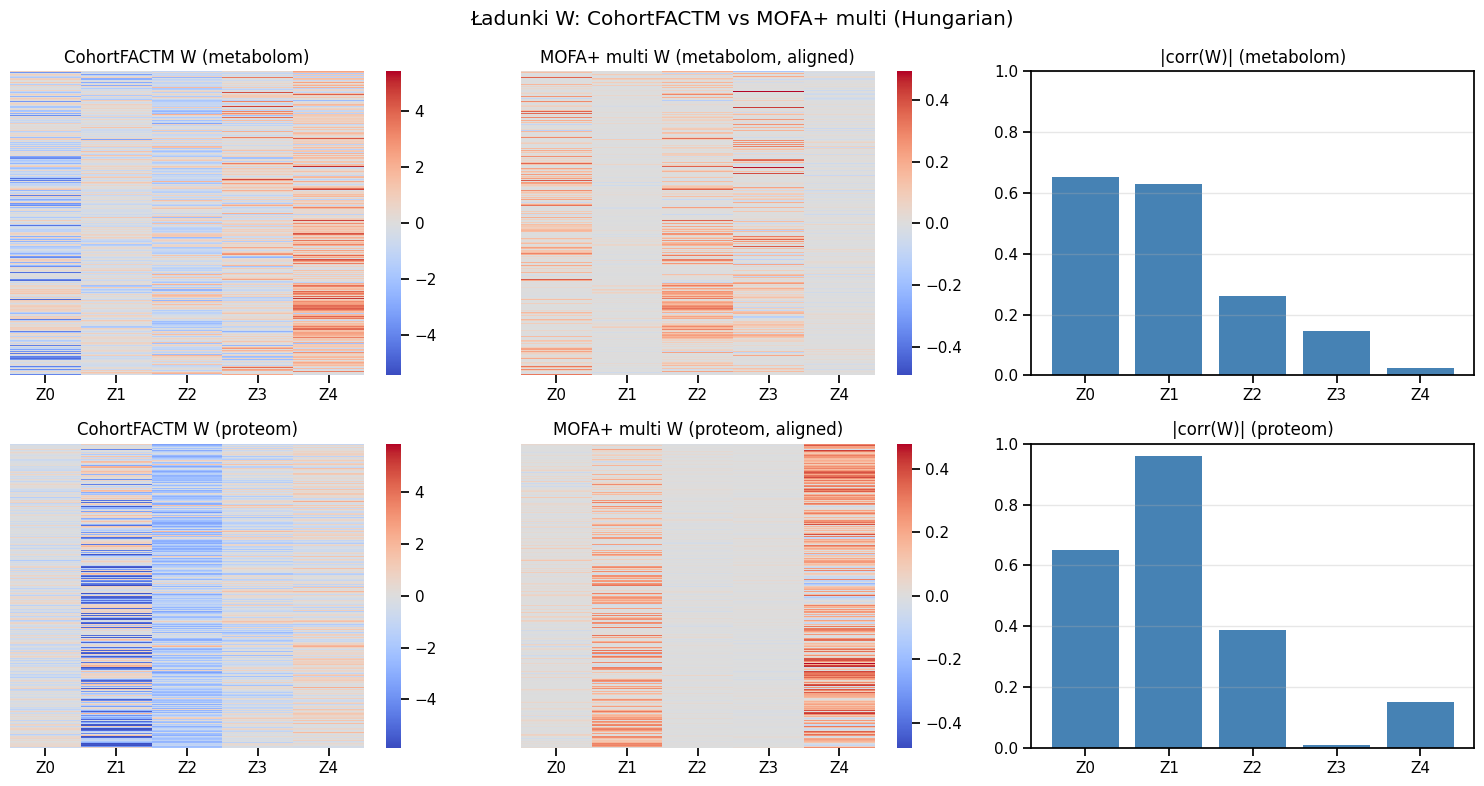

Średnie |corr(W)| per widok: [0.342, 0.432]


In [15]:
# 9.1 W cohort vs MOFA multi (Hungarian) + |corr(W)|
mode = 'per_severity'; d = get_data(mode)
mc = get_factm(mode, True); mm = get_mofa(mode, True)
perm = hungarian(np.asarray(mc.get_latent_factors()), mofa_Z(mm, d))
fl = [f'Z{k}' for k in range(K)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); wcorr = []
for vi, vname in enumerate(VIEW_NAMES):
    Wc = factm_W(mc, vi); Wm = mofa_W(mm, vi)[:, perm]
    cs = [abs(np.corrcoef(Wc[:, k], Wm[:, k])[0, 1]) if np.std(Wc[:, k]) > 0 and np.std(Wm[:, k]) > 0 else 0.0
          for k in range(K)]
    wcorr.append(cs); vmax = max(np.abs(Wc).max(), np.abs(Wm).max())
    sns.heatmap(Wc, cmap='coolwarm', center=0, vmin=-np.abs(Wc).max(), vmax=np.abs(Wc).max(), xticklabels=fl,
                yticklabels=False, ax=axes[vi, 0]); axes[vi, 0].set_title(f'CohortFACTM W ({vname})')
    sns.heatmap(Wm, cmap='coolwarm', center=0, vmin=-np.abs(Wm).max(), vmax=np.abs(Wm).max(), xticklabels=fl,
                yticklabels=False, ax=axes[vi, 1]); axes[vi, 1].set_title(f'MOFA+ multi W ({vname}, aligned)')
    axes[vi, 2].bar(fl, cs, color='steelblue'); axes[vi, 2].set_ylim(0, 1)
    axes[vi, 2].set_title(f'|corr(W)| ({vname})'); axes[vi, 2].grid(alpha=0.3, axis='y')
plt.suptitle('Ładunki W: CohortFACTM vs MOFA+ multi (Hungarian)'); plt.tight_layout(); plt.show()
print('Średnie |corr(W)| per widok:', [round(float(np.mean(c)), 3) for c in wcorr])

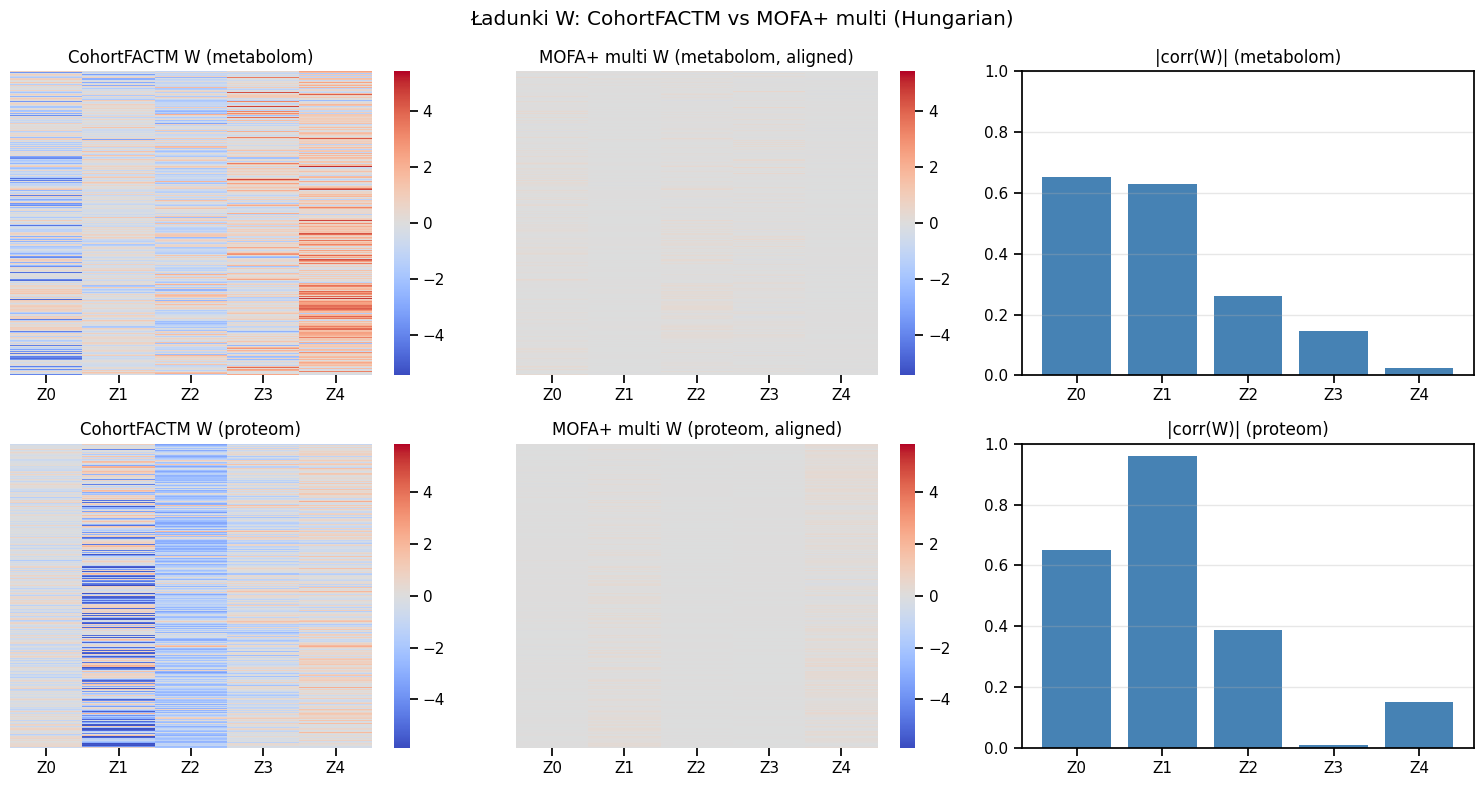

Średnie |corr(W)| per widok: [0.342, 0.432]


In [14]:
# 9.1 W cohort vs MOFA multi (Hungarian) + |corr(W)|
mode = 'per_severity'; d = get_data(mode)
mc = get_factm(mode, True); mm = get_mofa(mode, True)
perm = hungarian(np.asarray(mc.get_latent_factors()), mofa_Z(mm, d))
fl = [f'Z{k}' for k in range(K)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); wcorr = []
for vi, vname in enumerate(VIEW_NAMES):
    Wc = factm_W(mc, vi); Wm = mofa_W(mm, vi)[:, perm]
    cs = [abs(np.corrcoef(Wc[:, k], Wm[:, k])[0, 1]) if np.std(Wc[:, k]) > 0 and np.std(Wm[:, k]) > 0 else 0.0
          for k in range(K)]
    wcorr.append(cs); vmax = max(np.abs(Wc).max(), np.abs(Wm).max())
    sns.heatmap(Wc, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax, xticklabels=fl,
                yticklabels=False, ax=axes[vi, 0]); axes[vi, 0].set_title(f'CohortFACTM W ({vname})')
    sns.heatmap(Wm, cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax, xticklabels=fl,
                yticklabels=False, ax=axes[vi, 1]); axes[vi, 1].set_title(f'MOFA+ multi W ({vname}, aligned)')
    axes[vi, 2].bar(fl, cs, color='steelblue'); axes[vi, 2].set_ylim(0, 1)
    axes[vi, 2].set_title(f'|corr(W)| ({vname})'); axes[vi, 2].grid(alpha=0.3, axis='y')
plt.suptitle('Ładunki W: CohortFACTM vs MOFA+ multi (Hungarian)'); plt.tight_layout(); plt.show()
print('Średnie |corr(W)| per widok:', [round(float(np.mean(c)), 3) for c in wcorr])

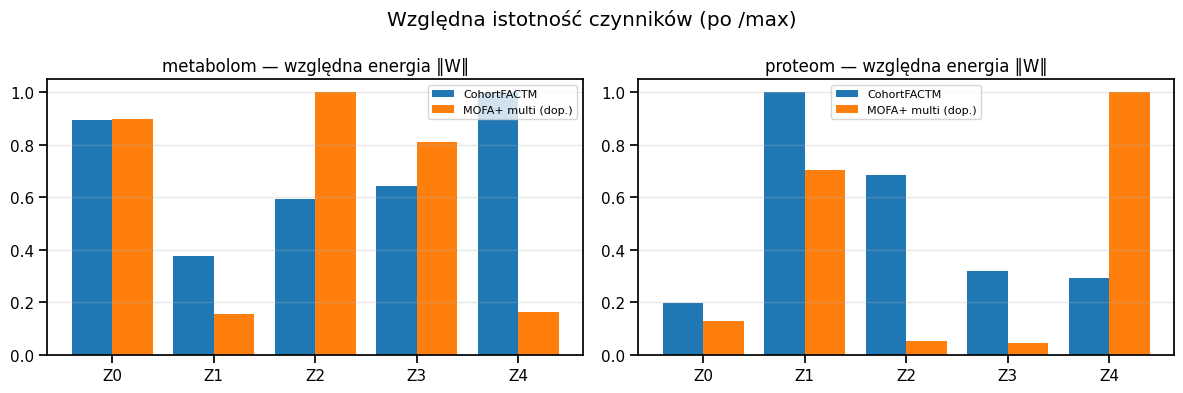

Top cechy per faktor (CohortFACTM):

=== Z0 ===
  metabolom: glutamine.conjugate.of.C6H10O2..1.. (-4.75), phenylacetylglutamate (-4.69), vanillactate (-4.67), tetrahydrocortisol.glucuronide (-4.63), glutamine.conjugate.of.C7H12O2. (-4.62), N6.succinyladenosine (-4.61)
  proteom: fibroblast.growth.factor.23.1 (-1.69), BMP.and.activin.membrane.bound.inhibitor (-1.59), fibroblast.growth.factor.23 (-1.51), calsyntenin.2 (-1.49), neural.proliferation..differentiation.and.control..1 (-1.41), C.type.lectin.domain.family.1..member.A (-1.40)

=== Z1 ===
  metabolom: phosphoethanolamine (-3.63), taurine (-3.25), X3.phosphoglycerate (-3.20), X1.stearoyl.2.oleoyl.GPS..18.0.18.1. (-3.17), sphinganine.1.phosphate (-2.94), flavin.adenine.dinucleotide..FAD. (-2.88)
  proteom: neurofibromin.2..merlin. (-5.88), syntaxin.8 (-5.76), negative.regulator.of.ubiquitin.like.proteins.1 (-5.75), SMAD.family.member.1 (-5.74), dynactin.1 (-5.71), erbb2.interacting.protein (-5.69)

=== Z2 ===
  metabolom: X1.palmit

In [15]:
# 9.2 względna energia ‖W‖ (faktory dopasowane, /max; surowej skali nie porównujemy)
mode = 'per_severity'; d = get_data(mode)
mc = get_factm(mode, True); mm = get_mofa(mode, True)
perm = hungarian(np.asarray(mc.get_latent_factors()), mofa_Z(mm, d)); fl = [f'Z{k}' for k in range(K)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vi, vname in zip(axes, range(2), VIEW_NAMES):
    e_c = np.linalg.norm(factm_W(mc, vi), axis=0); e_c = e_c / e_c.max()
    e_m = np.linalg.norm(mofa_W(mm, vi), axis=0)[perm]; e_m = e_m / e_m.max()
    x = np.arange(K)
    ax.bar(x - 0.2, e_c, 0.4, label='CohortFACTM'); ax.bar(x + 0.2, e_m, 0.4, label='MOFA+ multi (dop.)')
    ax.set_xticks(x); ax.set_xticklabels(fl); ax.set_title(f'{vname} — względna energia ‖W‖')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.suptitle('Względna istotność czynników (po /max)'); plt.tight_layout(); plt.show()

from pathlib import Path
import covid_data.load_covid as _lc
_b = Path(_lc.__file__).resolve().parent
feat = [pd.read_csv(_b / _lc.METABOLIC_FILE, index_col=0, nrows=0).columns.tolist(),
        pd.read_csv(_b / _lc.PROTEOMIC_FILE, index_col=0, nrows=0).columns.tolist()]
mc = get_factm('per_severity', True); TOPN = 6
print('Top cechy per faktor (CohortFACTM):')
for k in range(K):
    print(f'\n=== Z{k} ===')
    for vi, vname in enumerate(VIEW_NAMES):
        W = factm_W(mc, vi); o = np.argsort(np.abs(W[:, k]))[::-1][:TOPN]
        print(f'  {vname}: ' + ', '.join(f'{feat[vi][j]} ({W[j, k]:+.2f})' for j in o))

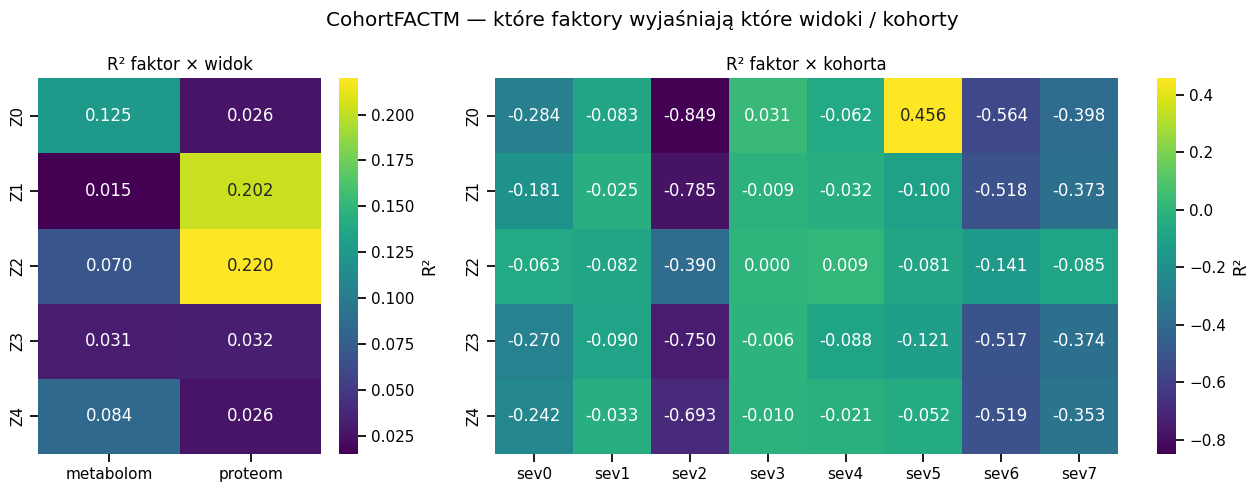

In [16]:
# 9.3 R² faktor × widok i faktor × kohorta (CohortFACTM)
mode = 'per_severity'; d = get_data(mode); views = d.views
mc = get_factm(mode, True); Z = np.asarray(mc.get_latent_factors())
names, codes = np.unique(d.cohorts, return_inverse=True); fl = [f'Z{k}' for k in range(K)]


def ve(Y, Yh):
    return 1 - ((Y - Yh) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()


R2_fv = np.array([[ve(np.asarray(views.simple[vi].data), np.outer(Z[:, k], factm_W(mc, vi)[:, k]))
                   for vi in range(views.num_simple)] for k in range(K)])
Ycat = np.hstack([np.asarray(views.simple[vi].data) for vi in range(views.num_simple)])
R2_fc = np.zeros((K, len(names)))
for k in range(K):
    Yh = np.hstack([np.outer(Z[:, k], factm_W(mc, vi)[:, k]) for vi in range(views.num_simple)])
    for ci in range(len(names)):
        R2_fc[k, ci] = ve(Ycat[codes == ci], Yh[codes == ci])
fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * K + 2.5), gridspec_kw={'width_ratios': [1, 2.2]})
sns.heatmap(R2_fv, annot=True, fmt='.3f', cmap='viridis', xticklabels=VIEW_NAMES, yticklabels=fl,
            ax=axes[0], cbar_kws={'label': 'R²'}); axes[0].set_title('R² faktor × widok')
sns.heatmap(R2_fc, annot=True, fmt='.3f', cmap='viridis', xticklabels=names, yticklabels=fl,
            ax=axes[1], cbar_kws={'label': 'R²'}); axes[1].set_title('R² faktor × kohorta')
plt.suptitle('CohortFACTM — które faktory wyjaśniają które widoki / kohorty')
plt.tight_layout(); plt.show()

## 10 — Podsumowanie (per_severity)

In [17]:
mode = 'per_severity'; d = get_data(mode); names = np.array(sorted(np.unique(d.cohorts)))
sev = np.array([severity_from_label(c) for c in names])
D_sev = np.abs(sev[:, None] - sev[None, :]); tri = np.triu_indices(len(names), 1)
rows = []
for label in MODELS:
    P, _ = get_profile(mode, label)
    z_row = df_Z[(df_Z['mode'] == mode) & (df_Z['model'] == label)].iloc[0]
    y_row = df_Y[(df_Y['mode'] == mode) & (df_Y['model'] == label)].iloc[0]
    rows.append({'model': label, 'R2': z_row['R2'],
                 'WHO_corr(Spearman)': round(spear(cohort_dist(P)[tri], D_sev[tri]), 3),
                 'ARI_Z': z_row['ARI'], 'ARI_Yhat': y_row['ARI'], 'sil_Yhat': y_row['silhouette']})
print(f'=== Zestawienie ({mode}, K={K}) ==='); print(pd.DataFrame(rows).round(3).to_string(index=False))

=== Zestawienie (per_severity, K=5) ===
            model    R2  WHO_corr(Spearman)  ARI_Z  ARI_Yhat  sil_Yhat
      CohortFACTM 0.392               0.870  0.555     0.525     0.187
MOFA+ multi-group 0.225              -0.131  0.034     0.027    -0.117


**Wnioski (CohortFACTM vs MOFA+ multi-group).**
1. **Sanity (sek. 1):** FACTM baseline ≈ MOFA single (ta sama podprzestrzeń `Z`) — dlatego
   dalej trzymamy tylko parę świadomą kohort.
2. **R²:** CohortFACTM ~0.39; MOFA multi ~0.23, bo centruje `Z` per grupa i odrzuca wariancję
   między-grupową (sek. 8) — *vs* dane per-grupa-centrowane jego R² jest wyższe.
3. **Gradient WHO (Spearman) i odzysk kohort:** CohortFACTM wyraźnie wyżej; MOFA multi ≈0 w
   `Z` (artefakt centrowania), niski też w `Ŷ`.
4. **Konkluzja:** do pytania „czym różnią się kohorty" właściwy jest CohortFACTM (jawny `γ·δ`);
   MOFA+ multi-group modeluje strukturę wewnątrz grup — inny cel.
